# 👩‍💻 Experiment with Initialization and Optimizer Combinations

## 📋 Overview
In this hands-on lab, you'll explore how different weight initialization techniques and optimization algorithms affect neural network training. You'll implement He and Xavier initialization methods and experiment with popular optimizers like SGD with momentum, Adam, and RMSprop. By comparing their convergence patterns and performance metrics, you'll gain practical insights into selecting the right combination for efficient model training—a crucial skill for deep learning practitioners working on real-world applications.

In [1]:
# Starter code
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import time

# Set random seed for reproducibility
torch.manual_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Data loading and preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

# Load FashionMNIST dataset
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)

# Create data loaders
batch_size = 64
train_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False
)

# Define the CNN model architecture
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

Using device: cuda


## Task 1: Implement Weight Initialization Techniques
**Context:** Weight initialization is critical for neural network training. Poor initialization can lead to vanishing/exploding gradients, while proper initialization helps achieve faster convergence.

**Steps:**

1. Create a function to initialize the CNN model with He initialization

    - Use `nn.init.kaiming_normal_` function to initialize convolutional and linear layers
    - Remember that He initialization is designed for ReLU activations

2. Create a function to initialize the CNN model with Xavier/Glorot initialization

    - Use `nn.init.xavier_normal_` function for weight initialization
    - Xavier initialization is better suited for tanh and sigmoid activations, but we'll compare its performance with ReLU

3. Test both initialization methods by creating two separate model instances

In [3]:
# He Initialization (Kaiming)
def init_he(model):
    for m in model.modules():
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)
                
#  Xavier Initialization (Glorot)
def init_xavier(model):
    for m in model.modules():
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

# Applying Initialization to CNN Model
model_he = CNN()
init_he(model_he)

model_xavier = CNN()
init_xavier(model_xavier)

## Task 2: Configure Optimizers for Training
**Context:** Different optimizers use different strategies to update model weights, which can significantly impact training dynamics, convergence speed, and final model performance.

**Steps:**

1. Create a function to set up SGD with momentum optimizer

    - Use `torch.optim.SGD` with appropriate learning rate and momentum parameters
    - Set momentum to 0.9 for stability

2. Create a function to configure Adam optimizer

    - Use `torch.optim.Adam` with appropriate learning rate
    - Use default beta values unless you want to experiment with them

3. Create a function to configure RMSprop optimizer

    - Use `torch.optim.RMSprop` with appropriate learning rate
    - Set alpha (smoothing constant) to 0.99

In [4]:
# ============================
# Task 2: Optimizer Setup
# ============================

def get_sgd_optimizer(model, lr=0.01, momentum=0.9):
    """
    SGD with momentum (0.9 recommended for stability)
    """
    return torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)


def get_adam_optimizer(model, lr=0.001):
    """
    Adam optimizer with default betas (0.9, 0.999)
    """
    return torch.optim.Adam(model.parameters(), lr=lr)


def get_rmsprop_optimizer(model, lr=0.001, alpha=0.99):
    """
    RMSprop optimizer with smoothing constant alpha=0.99
    """
    return torch.optim.RMSprop(model.parameters(), lr=lr, alpha=alpha)


# ============================
# Example usage
# ============================

model = CNN()  # or any model you defined

optimizer_sgd = get_sgd_optimizer(model, lr=0.01)
optimizer_adam = get_adam_optimizer(model, lr=0.001)
optimizer_rmsprop = get_rmsprop_optimizer(model, lr=0.001)

## Task 3: Implement Training Loop and Experiments
**Context:** A systematic approach to experimentation helps isolate the effects of initialization and optimizer choices on model training.

**Steps:**

1. Create a training function that takes a model, optimizer, and number of epochs

    - Loop through batches of training data
    - Calculate loss using `nn.CrossEntropyLoss()`
    - Track and return training loss history, validation accuracy per epoch, and training time

2. Run experiments combining different initialization methods and optimizers

    - Create a total of 6 combinations: 2 initializations × 3 optimizers
    - Train each combination for the same number of epochs (e.g., 10)

3. Store results in a dictionary or list for later analysis

In [10]:
import time
import torch.nn.functional as F

# ============================================
# Training Function
# ============================================

def train_model(model, optimizer, train_loader, test_loader, epochs=5, device="cuda"):
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_accuracies = []

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Validation accuracy
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        val_accuracies.append(accuracy)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Val Acc: {accuracy:.2f}%")

    total_time = time.time() - start_time

    return {
        "train_losses": train_losses,
        "val_accuracies": val_accuracies,
        "training_time": total_time
    }


# ============================================
# Experiment Runner (6 combinations)
# ============================================

def run_experiments(train_loader, test_loader, device="cuda"):
    results = {}

    initializations = {
        "He": init_he,
        "Xavier": init_xavier
    }

    optimizers = {
        "SGD": get_sgd_optimizer,
        "Adam": get_adam_optimizer,
        "RMSprop": get_rmsprop_optimizer
    }

    for init_name, init_fn in initializations.items():
        for opt_name, opt_fn in optimizers.items():

            print(f"\nRunning: {init_name} + {opt_name}")

            # 1. Create fresh model
            model = CNN().to(device)

            # 2. Apply initialization
            init_fn(model)

            # 3. Create optimizer (THIS WAS MISSING)
            optimizer = opt_fn(model)

            # 4. Unique key for results
            exp_key = f"{init_name}_{opt_name}"

            # 5. Train and store results
            results[exp_key] = train_model(
                model=model,
                optimizer=optimizer,
                train_loader=train_loader,
                test_loader=test_loader,
                epochs=5,
                device=device
            )

    return results

# ============================================
# Run All Experiments
# ============================================

results = run_experiments(train_loader, test_loader, device=device)
print("All experiments completed!")


Running: He + SGD
Epoch 1/5 | Loss: 0.4351 | Val Acc: 87.78%
Epoch 2/5 | Loss: 0.2739 | Val Acc: 89.03%
Epoch 3/5 | Loss: 0.2296 | Val Acc: 88.68%
Epoch 4/5 | Loss: 0.2011 | Val Acc: 90.62%
Epoch 5/5 | Loss: 0.1810 | Val Acc: 91.32%

Running: He + Adam
Epoch 1/5 | Loss: 0.4083 | Val Acc: 89.52%
Epoch 2/5 | Loss: 0.2629 | Val Acc: 90.00%
Epoch 3/5 | Loss: 0.2147 | Val Acc: 90.74%
Epoch 4/5 | Loss: 0.1827 | Val Acc: 90.93%
Epoch 5/5 | Loss: 0.1551 | Val Acc: 91.39%

Running: He + RMSprop
Epoch 1/5 | Loss: 0.4445 | Val Acc: 87.54%
Epoch 2/5 | Loss: 0.2639 | Val Acc: 90.17%
Epoch 3/5 | Loss: 0.2144 | Val Acc: 90.33%
Epoch 4/5 | Loss: 0.1783 | Val Acc: 90.87%
Epoch 5/5 | Loss: 0.1478 | Val Acc: 90.88%

Running: Xavier + SGD
Epoch 1/5 | Loss: 0.4905 | Val Acc: 87.22%
Epoch 2/5 | Loss: 0.3117 | Val Acc: 89.01%
Epoch 3/5 | Loss: 0.2663 | Val Acc: 89.87%
Epoch 4/5 | Loss: 0.2329 | Val Acc: 90.45%
Epoch 5/5 | Loss: 0.2102 | Val Acc: 91.36%

Running: Xavier + Adam
Epoch 1/5 | Loss: 0.4035 | Val 

## Task 4: Visualize and Analyze Results
**Context:** Visualization is essential for understanding complex training dynamics and identifying the best-performing configurations.

**Steps:**

1. Create plots for training loss across epochs for each configuration

    - Use matplotlib to create line plots
    - Use different colors or line styles for different configurations
    - Include a legend to identify each configuration

2. Create plots for validation accuracy across epochs

    - Plot accuracy curves for all configurations on the same graph
    - Add appropriate labels, title, and legend

3. Create a bar chart comparing final accuracy and training time


Running: He + SGD
Epoch 1/5 | Loss: 0.4403 | Val Acc: 87.97%
Epoch 2/5 | Loss: 0.2829 | Val Acc: 89.34%
Epoch 3/5 | Loss: 0.2394 | Val Acc: 90.17%
Epoch 4/5 | Loss: 0.2109 | Val Acc: 90.28%
Epoch 5/5 | Loss: 0.1866 | Val Acc: 90.02%

Running: He + Adam
Epoch 1/5 | Loss: 0.4319 | Val Acc: 88.68%
Epoch 2/5 | Loss: 0.2711 | Val Acc: 89.68%
Epoch 3/5 | Loss: 0.2263 | Val Acc: 89.69%
Epoch 4/5 | Loss: 0.1928 | Val Acc: 90.86%
Epoch 5/5 | Loss: 0.1677 | Val Acc: 91.29%

Running: He + RMSprop
Epoch 1/5 | Loss: 0.4499 | Val Acc: 87.83%
Epoch 2/5 | Loss: 0.2596 | Val Acc: 89.22%
Epoch 3/5 | Loss: 0.2069 | Val Acc: 90.45%
Epoch 4/5 | Loss: 0.1713 | Val Acc: 91.66%
Epoch 5/5 | Loss: 0.1397 | Val Acc: 91.26%

Running: Xavier + SGD
Epoch 1/5 | Loss: 0.4932 | Val Acc: 87.47%
Epoch 2/5 | Loss: 0.3069 | Val Acc: 88.84%
Epoch 3/5 | Loss: 0.2635 | Val Acc: 90.45%
Epoch 4/5 | Loss: 0.2339 | Val Acc: 89.82%
Epoch 5/5 | Loss: 0.2091 | Val Acc: 90.66%

Running: Xavier + Adam
Epoch 1/5 | Loss: 0.4150 | Val 

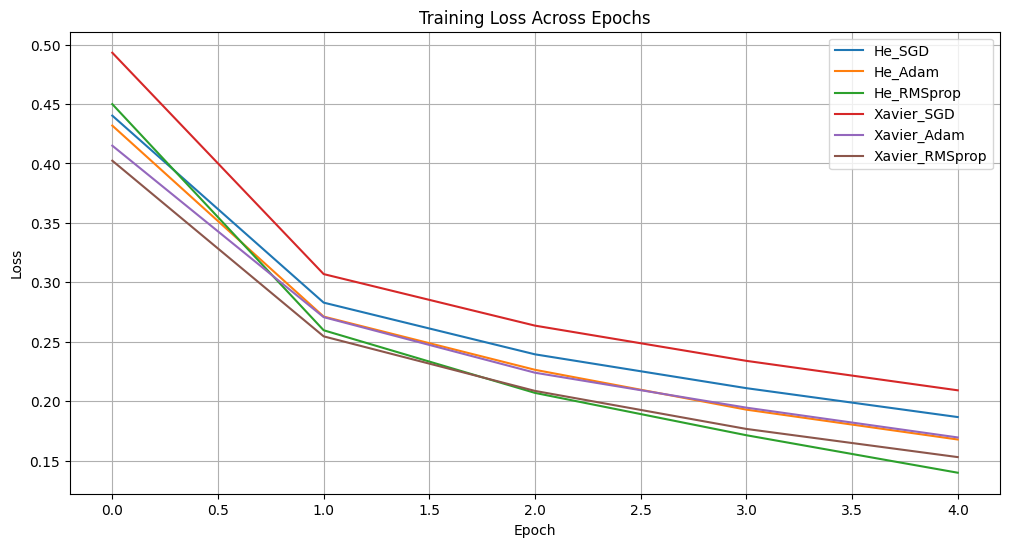

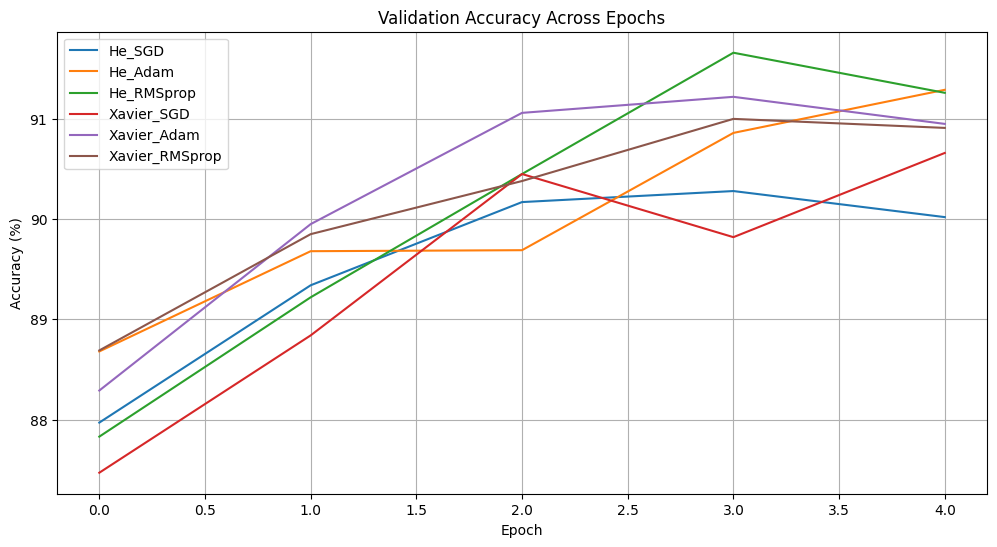

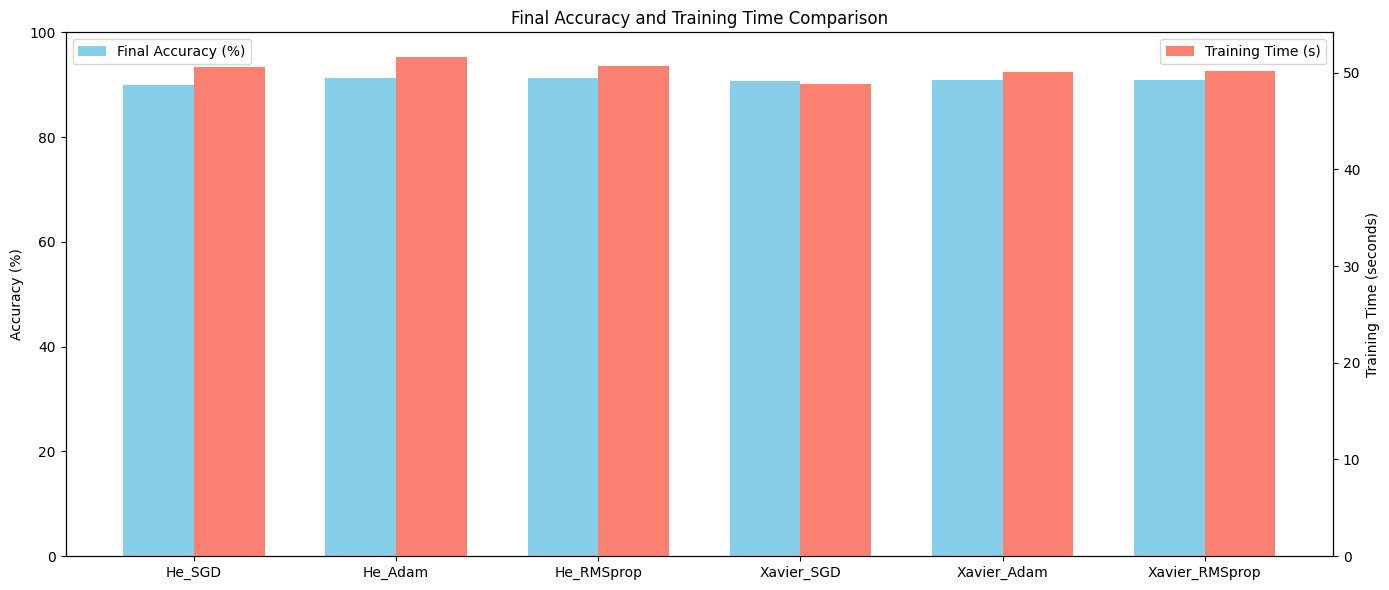

In [12]:
results = run_experiments(train_loader, test_loader, device=device)



import matplotlib.pyplot as plt
import numpy as np

# ============================================
# Plot Training Loss for All Configurations
# ============================================

def plot_training_loss(results):
    plt.figure(figsize=(12, 6))

    for config, metrics in results.items():
        plt.plot(metrics["train_losses"], label=config)

    plt.title("Training Loss Across Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


# ============================================
# Plot Validation Accuracy for All Configurations
# ============================================

def plot_validation_accuracy(results):
    plt.figure(figsize=(12, 6))

    for config, metrics in results.items():
        plt.plot(metrics["val_accuracies"], label=config)

    plt.title("Validation Accuracy Across Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.grid(True)
    plt.show()


# ============================================
# Bar Chart: Final Accuracy & Training Time
# ============================================

def plot_final_performance(results):
    configs = list(results.keys())
    final_acc = [results[c]["val_accuracies"][-1] for c in configs]
    train_time = [results[c]["training_time"] for c in configs]

    x = np.arange(len(configs))
    width = 0.35

    fig, ax1 = plt.subplots(figsize=(14, 6))

    # Accuracy bars
    ax1.bar(x - width/2, final_acc, width, label="Final Accuracy (%)", color="skyblue")
    ax1.set_ylabel("Accuracy (%)")
    ax1.set_ylim(0, 100)

    # Training time bars
    ax2 = ax1.twinx()
    ax2.bar(x + width/2, train_time, width, label="Training Time (s)", color="salmon")
    ax2.set_ylabel("Training Time (seconds)")

    plt.xticks(x, configs, rotation=45)
    plt.title("Final Accuracy and Training Time Comparison")

    # Combined legend
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")

    plt.tight_layout()
    plt.show()


# ============================================
# Run All Plots
# ============================================

plot_training_loss(results)
plot_validation_accuracy(results)
plot_final_performance(results)

## Task 5: Analyze and Document Findings
**Context:** Drawing correct conclusions from experimental results is a critical skill in machine learning research and practice.

**Steps:**

1. Identify the best-performing initialization-optimizer combination based on:

    - Final validation accuracy
    - Convergence speed (epochs to reach a target accuracy)
    - Training time efficiency

2. Analyze the relationship between initialization methods and optimizers

    - Identify which combinations work well together
    - Note any initialization-optimizer combinations that performed poorly

3. Document your findings with specific evidence from the experiments

In [13]:
import pandas as pd
import numpy as np

def analyze_results(results, target_accuracy=90):
    summary = []

    for config, metrics in results.items():
        train_losses = metrics["train_losses"]
        val_acc = metrics["val_accuracies"]
        time_taken = metrics["training_time"]

        final_acc = val_acc[-1]

        # Convergence speed: epoch where accuracy first exceeds target
        try:
            epoch_to_target = next(i for i, a in enumerate(val_acc) if a >= target_accuracy) + 1
        except StopIteration:
            epoch_to_target = None  # Never reached target

        summary.append({
            "Configuration": config,
            "Final Accuracy (%)": final_acc,
            "Epochs to Reach Target Acc": epoch_to_target,
            "Training Time (s)": time_taken
        })

    df = pd.DataFrame(summary)
    df = df.sort_values(by="Final Accuracy (%)", ascending=False)

    return df


# Run analysis
summary_df = analyze_results(results, target_accuracy=90)
summary_df

,Configuration,Final Accuracy (%),Epochs to Reach Target Acc,Training Time (s)
1,He_Adam,91.29,4,51.594867
2,He_RMSprop,91.26,3,50.681053
4,Xavier_Adam,90.95,3,50.040216
5,Xavier_RMSprop,90.91,3,50.177395
3,Xavier_SGD,90.66,3,48.876909
0,He_SGD,90.02,3,50.583281
